In [7]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing import image
import warnings
warnings.filterwarnings('ignore')

In [4]:
train_dir = '/kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset/train'
test_dir = '/kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset/test'

In [5]:
classes = os.listdir(train_dir)
print(classes)

['Normal', 'Viral Pneumonia', 'Covid']


In [8]:
# for loop to show images
def plot_classes(path,img_classes):
    plt.figure(figsize = (15,15))
    for i , cat in enumerate (img_classes):
        fol_img_path = train_dir + "/" + cat
        img_in_fol = os.listdir(fol_img_path)
        f_i = img_in_fol[0]
        first_image_path = fol_img_path + "/" + f_i
        img = image.load_img(first_image_path)
        img_array = image.img_to_array(img) / 255
        plt.subplot(1,len(img_classes),i+1)
        plt.imshow(img_array)
        plt.title(cat)
        plt.axis('off')
    plt.show()

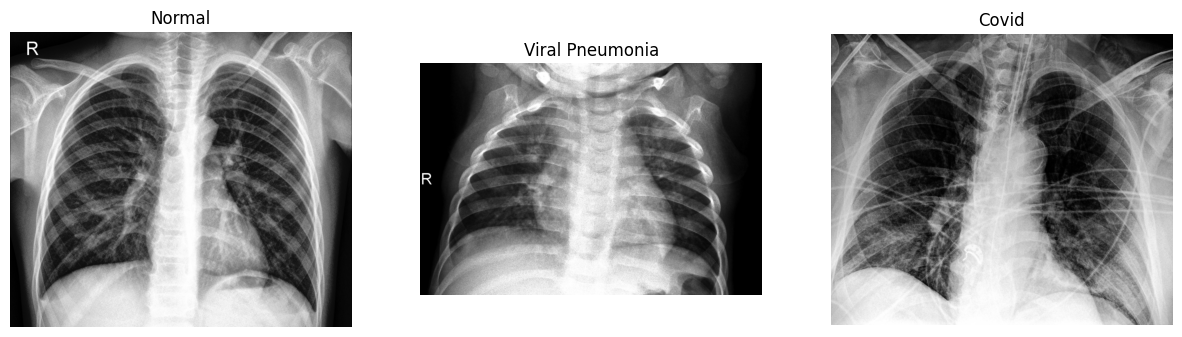

In [9]:
plot_classes(train_dir,classes)

In [10]:
train_dataGen = ImageDataGenerator(rescale = 1./255,
                                   zoom_range=0.2,
                                   rotation_range=20,width_shift_range=0.2,
                                   height_shift_range=0.2,horizontal_flip=True)
test_dataGen = ImageDataGenerator(rescale = 1./255)

In [12]:
train_data = train_dataGen.flow_from_directory(train_dir,
                                               target_size = (224,224),
                                               batch_size = 32,
                                               class_mode = 'categorical',subset='training')
test_data = test_dataGen.flow_from_directory(test_dir,
                                             target_size = (224,224),
                                             batch_size = 32,
                                             class_mode = 'categorical')

Found 251 images belonging to 3 classes.
Found 66 images belonging to 3 classes.


In [13]:
img , label = next(iter(train_data))

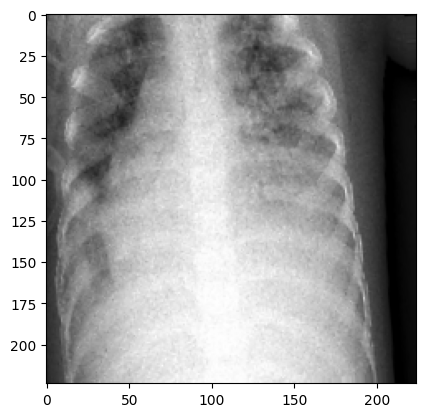

In [16]:
plt.imshow(img[0])
plt.show()

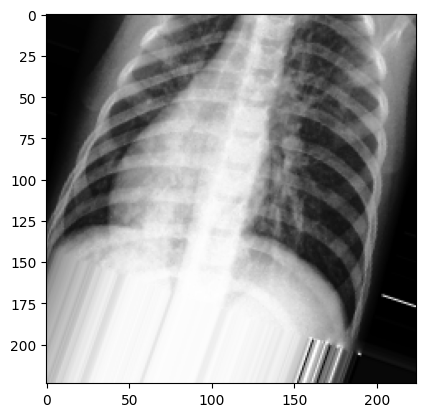

In [17]:
plt.imshow(img[10])
plt.show()

In [21]:
# Building CNN 

model = Sequential()
model.add(Conv2D(32,(3,3),activation = 'relu',input_shape = (224,224,3),padding = 'same'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation = 'relu',padding = 'same'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),activation = 'relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(64,activation = 'relu'))
model.add(Dense(128,activation = 'relu'))
model.add(Dense(256,activation = 'relu'))
model.add(Dense(3,activation = 'softmax'))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 54, 54, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 27, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 93312)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     5,972,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,107,395 (23.30 MB)

 Trainable params: 6,107,395 (23.30 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(optimizer = 'adam',loss = 'categorical_crossentropy',metrics = ['accuracy'])
history = model.fit(train_data,epochs = 3,validation_data=test_data)

Epoch 1/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4183 - loss: 1.0886 - val_accuracy: 0.6061 - val_loss: 0.9785
Epoch 2/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.4382 - loss: 1.0101 - val_accuracy: 0.6212 - val_loss: 0.8391
Epoch 3/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.6733 - loss: 0.7718 - val_accuracy: 0.6364 - val_loss: 0.6208


In [23]:
history.history

{'accuracy': [0.4183267056941986, 0.43824702501296997, 0.6733067631721497],
 'loss': [1.0886046886444092, 1.0100980997085571, 0.7717662453651428],
 'val_accuracy': [0.6060606241226196, 0.6212121248245239, 0.6363636255264282],
 'val_loss': [0.9784618616104126, 0.8391293287277222, 0.6207849383354187]}

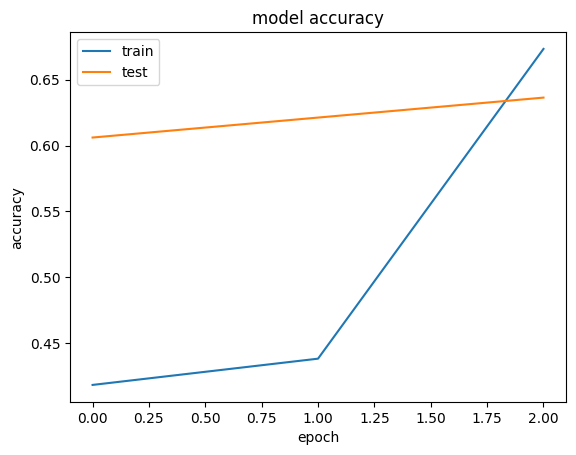

In [ ]:
# plot accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

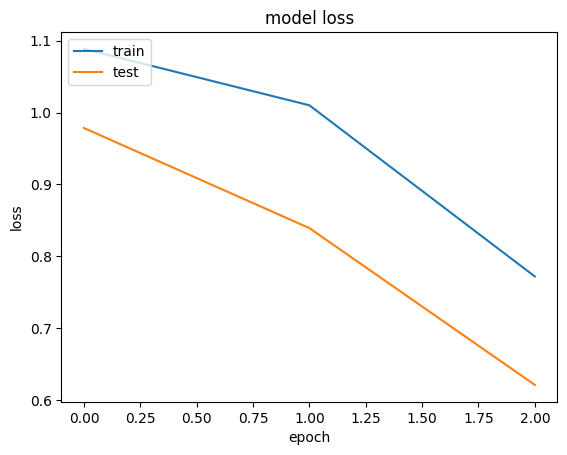

In [25]:
# plot loss

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [26]:
# save model
model.save('covid19.h5')

In [27]:
from tensorflow.keras.models import load_model

In [28]:
model_loaded = load_model('covid19.h5')

In [29]:
model_loaded.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 54, 54, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 27, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 93312)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     5,972,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,107,397 (23.30 MB)

 Trainable params: 6,107,395 (23.30 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)